# Car Price Prediction with Machine Learning

**OASIS INFOBYTE — Data Science | Task 3**

**Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

**Tech Stack:** Python · pandas · scikit-learn · matplotlib · seaborn · Jupyter Notebook

**Dataset:** Vehicle Dataset from CarDekho (Kaggle – nehalbirla/vehicle-dataset-from-cardekho)

## 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

# Compatible with both old and new matplotlib
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('ggplot')

sns.set_palette('husl')

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load the Dataset

The dataset contains information about used cars listed on [CarDekho](https://www.cardekho.com).

| Column | Description |
|--------|-------------|
| Car_Name | Name / model of the car |
| Year | Year of purchase |
| Selling_Price | Price the owner wants to sell at (target, in lakhs INR) |
| Present_Price | Current ex-showroom price (in lakhs INR) |
| Kms_Driven | Distance driven (km) |
| Fuel_Type | Petrol / Diesel / CNG |
| Seller_Type | Dealer / Individual |
| Transmission | Manual / Automatic |
| Owner | Number of previous owners (0, 1, 3) |

In [23]:
df = pd.read_csv('car_data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Data Cleaning

- Handle null values
- Remove duplicates
- Address inconsistent categorical values

In [24]:
# Basic info
print('--- Dataset Info ---')
df.info()
print('\n--- Null values ---')
print(df.isnull().sum())
print('\n--- Duplicate rows ---')
print(df.duplicated().sum())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

--- Null values ---
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

--- Duplicate rows ---
2


In [25]:
# Drop exact duplicates if any
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after dropping duplicates: {df.shape}')

Shape after dropping duplicates: (299, 9)


In [26]:
# Check categorical value consistency
print('Fuel_Type unique:', df['Fuel_Type'].unique())
print('Seller_Type unique:', df['Seller_Type'].unique())
print('Transmission unique:', df['Transmission'].unique())
print('Owner unique:', df['Owner'].unique())

Fuel_Type unique: ['Petrol' 'Diesel' 'CNG']
Seller_Type unique: ['Dealer' 'Individual']
Transmission unique: ['Manual' 'Automatic']
Owner unique: [0 1 3]


In [27]:
# Standardise categorical strings (lowercase + strip) – defensive cleaning
for col in ['Fuel_Type', 'Seller_Type', 'Transmission']:
    df[col] = df[col].str.strip().str.title()

print('After standardisation:')
print(df['Fuel_Type'].value_counts())
print(df['Seller_Type'].value_counts())
print(df['Transmission'].value_counts())

After standardisation:
Petrol    239
Diesel     58
Cng         2
Name: Fuel_Type, dtype: int64
Dealer        193
Individual    106
Name: Seller_Type, dtype: int64
Manual       260
Automatic     39
Name: Transmission, dtype: int64


## 4. Feature Engineering

1. **Car Age** – calculated from the Year column (relative to 2018, the latest year in the dataset).
2. **Brand** – extracted from the Car_Name column (first token).

In [28]:
# Car Age
current_year = 2018   # dataset max year
df['Car_Age'] = current_year - df['Year']

# Brand extraction (first word of Car_Name)
df['Brand'] = df['Car_Name'].str.split().str[0].str.lower()

print('Top 10 brands:')
print(df['Brand'].value_counts().head(10))
df[['Car_Name', 'Brand', 'Year', 'Car_Age']].head(10)

Top 10 brands:
city        26
bajaj       25
royal       17
corolla     17
honda       17
hero        15
verna       14
etios       11
brio        10
fortuner    10
Name: Brand, dtype: int64


,Car_Name,Brand,Year,Car_Age
0,ritz,ritz,2014,4
1,sx4,sx4,2013,5
2,ciaz,ciaz,2017,1
3,wagon r,wagon,2011,7
4,swift,swift,2014,4
5,vitara brezza,vitara,2018,0
6,ciaz,ciaz,2015,3
7,s cross,s,2015,3
8,ciaz,ciaz,2016,2
9,ciaz,ciaz,2015,3


## 5. Exploratory Data Analysis (EDA)

### 5.1 Descriptive Statistics

In [29]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478,4.384615
std,2.896868,4.984240,8.567887,39015.170352,0.248720,2.896868
min,2003.000000,0.100000,0.320000,500.000000,0.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000,2.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000,4.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000,6.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000,15.000000


**Observation:** Selling prices range from 0.1 to 35 lakhs. Most cars are relatively new (median year 2014) and have moderate mileage.

### 5.2 Distribution of Selling Prices

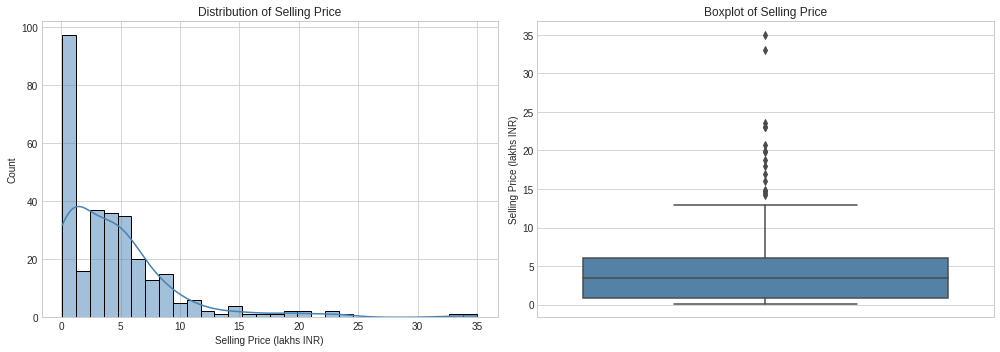

Mean Selling Price : 4.59 lakhs
Median Selling Price: 3.51 lakhs


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Selling_Price'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Selling Price')
axes[0].set_xlabel('Selling Price (lakhs INR)')

sns.boxplot(y=df['Selling_Price'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Selling Price')
axes[1].set_ylabel('Selling Price (lakhs INR)')

plt.tight_layout()
plt.show()

print(f'Mean Selling Price : {df["Selling_Price"].mean():.2f} lakhs')
print(f'Median Selling Price: {df["Selling_Price"].median():.2f} lakhs')

**Observation:** The selling-price distribution is right-skewed; a few high-value cars pull the mean above the median.

### 5.3 Price vs Fuel Type (Box Plot)

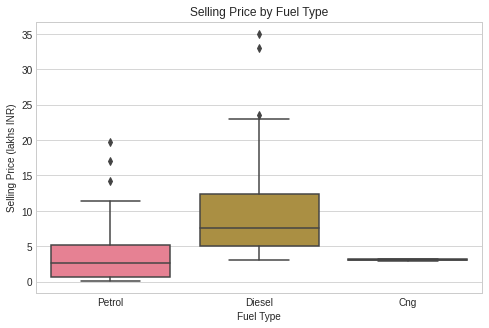

                mean  median  count
Fuel_Type                          
Cng         3.100000    3.10      2
Diesel     10.102759    7.60     58
Petrol      3.264184    2.65    239


In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (lakhs INR)')
plt.show()

print(df.groupby('Fuel_Type')['Selling_Price'].agg(['mean', 'median', 'count']))

**Observation:** Diesel cars command higher average selling prices than Petrol cars. CNG samples are very few.

### 5.4 Price vs Car Age (Scatter Plot)

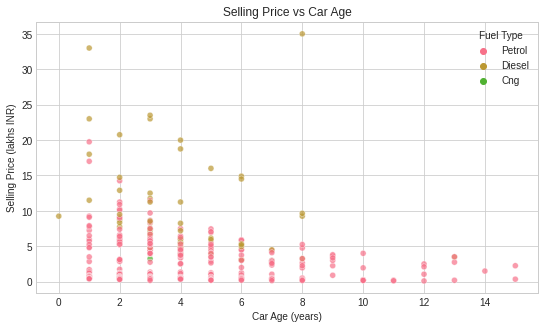

In [32]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Car_Age', y='Selling_Price', hue='Fuel_Type', data=df, alpha=0.7)
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price (lakhs INR)')
plt.legend(title='Fuel Type')
plt.show()

**Observation:** Clear negative relationship – older cars sell for less. Diesel cars still tend to sit higher for the same age.

### 5.5 Additional Quick Visuals

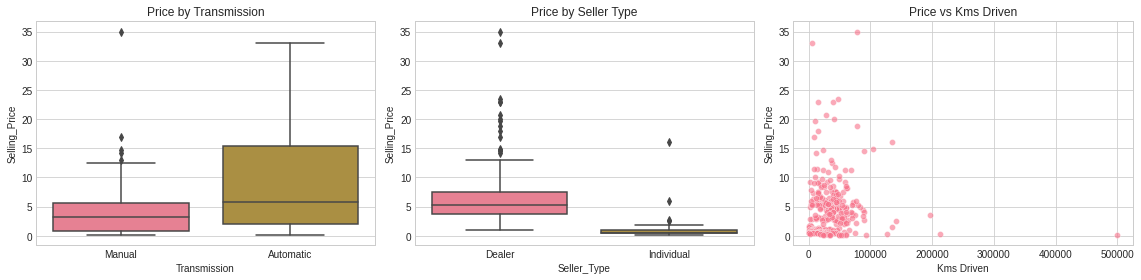

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(x='Transmission', y='Selling_Price', data=df, ax=axes[0])
axes[0].set_title('Price by Transmission')

sns.boxplot(x='Seller_Type', y='Selling_Price', data=df, ax=axes[1])
axes[1].set_title('Price by Seller Type')

sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df, ax=axes[2], alpha=0.6)
axes[2].set_title('Price vs Kms Driven')
axes[2].set_xlabel('Kms Driven')

plt.tight_layout()
plt.show()

**Observation:** Automatic cars and dealer-sold cars tend to have higher prices. Higher mileage generally correlates with lower price.

## 6. Encode Categorical Variables

We use **Label Encoding** for simplicity (also suitable for tree-based models). One-Hot Encoding is equally valid; Label Encoding keeps dimensionality low for this small dataset.

In [34]:
df_model = df.copy()

# Label encode categorical columns
le_dict = {}
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Fuel_Type: {'Cng': 0, 'Diesel': 1, 'Petrol': 2}
Seller_Type: {'Dealer': 0, 'Individual': 1}
Transmission: {'Automatic': 0, 'Manual': 1}
Brand: {'800': 0, 'activa': 1, 'alto': 2, 'amaze': 3, 'bajaj': 4, 'baleno': 5, 'brio': 6, 'camry': 7, 'ciaz': 8, 'city': 9, 'corolla': 10, 'creta': 11, 'dzire': 12, 'elantra': 13, 'eon': 14, 'ertiga': 15, 'etios': 16, 'fortuner': 17, 'grand': 18, 'hero': 19, 'honda': 20, 'hyosung': 21, 'i10': 22, 'i20': 23, 'ignis': 24, 'innova': 25, 'jazz': 26, 'ktm': 27, 'land': 28, 'mahindra': 29, 'omni': 30, 'ritz': 31, 'royal': 32, 's': 33, 'suzuki': 34, 'swift': 35, 'sx4': 36, 'tvs': 37, 'um': 38, 'verna': 39, 'vitara': 40, 'wagon': 41, 'xcent': 42, 'yamaha': 43}


## 7. Feature Correlation Heatmap

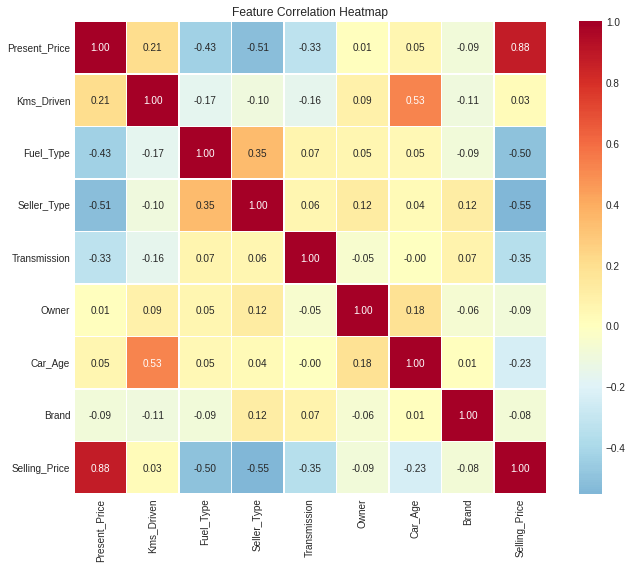

In [35]:
# Select numeric / encoded features for modelling
feature_cols = ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type',
                'Transmission', 'Owner', 'Car_Age', 'Brand']

corr_matrix = df_model[feature_cols + ['Selling_Price']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observation:** `Present_Price` has the strongest positive correlation with `Selling_Price`. `Car_Age` and `Kms_Driven` show moderate negative correlation, as expected.

## 8. Train / Test Split

In [36]:
X = df_model[feature_cols]
y = df_model['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set : {X_test.shape[0]} samples')

Train set: 239 samples
Test set : 60 samples


## 9. Train Regression Models

We train **three** models:
1. Linear Regression (baseline)
2. Random Forest Regressor
3. Gradient Boosting Regressor

In [37]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model, 'y_pred': y_pred}
    print(f'{name:20s} | MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.4f}')

Linear Regression    | MAE: 1.540 | RMSE: 2.583 | R²: 0.7411
Random Forest        | MAE: 1.302 | RMSE: 3.173 | R²: 0.6093
Gradient Boosting    | MAE: 1.196 | RMSE: 2.707 | R²: 0.7158


## 10. Model Evaluation Summary

In [38]:
results_df = pd.DataFrame({
    name: {'MAE': res['MAE'], 'RMSE': res['RMSE'], 'R²': res['R2']}
    for name, res in results.items()
}).T

print(results_df.round(4))

best_name = results_df['R²'].idxmax()
print(f'\nBest model by R² score: {best_name} (R² = {results_df.loc[best_name, "R²"]:.4f})')

                      MAE    RMSE      R²
Linear Regression  1.5405  2.5830  0.7411
Random Forest      1.3020  3.1731  0.6093
Gradient Boosting  1.1963  2.7066  0.7158

Best model by R² score: Linear Regression (R² = 0.7411)


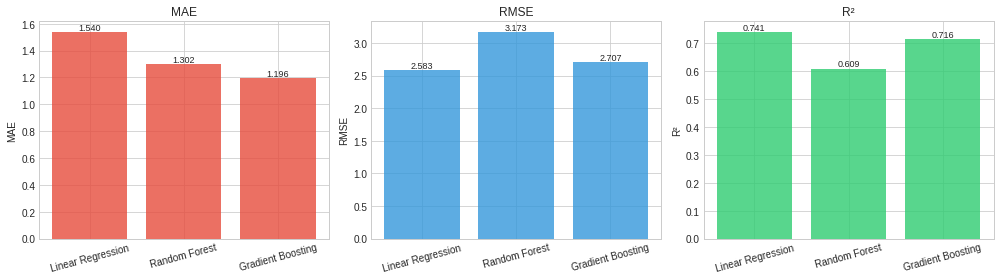

In [39]:
# Visual comparison of metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['MAE', 'RMSE', 'R²']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, metric, color in zip(axes, metrics, colors):
    vals = [results[m][metric if metric != 'R²' else 'R2'] for m in results]
    bars = ax.bar(list(results.keys()), vals, color=color, alpha=0.8)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 11. Feature Importance (Best Model)

Tree-based models provide feature-importance scores that help interpret which variables drive the predictions most strongly.

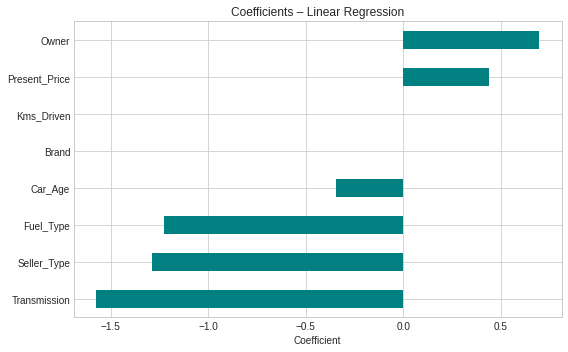

Owner            0.699255
Present_Price    0.441311
Kms_Driven      -0.000009
Brand           -0.000160
Car_Age         -0.342980
Fuel_Type       -1.224954
Seller_Type     -1.289115
Transmission    -1.576412
dtype: float64


In [40]:
best_model = results[best_name]['model']

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    importances.plot(kind='barh', color='teal')
    plt.title(f'Feature Importance – {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print(importances.sort_values(ascending=False))
else:
    # Linear Regression coefficients
    coefs = pd.Series(best_model.coef_, index=feature_cols).sort_values()
    plt.figure(figsize=(8, 5))
    coefs.plot(kind='barh', color='teal')
    plt.title(f'Coefficients – {best_name}')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()
    print(coefs.sort_values(ascending=False))

**Interpretation:** `Present_Price` is by far the most influential feature. Car age, fuel type and transmission also contribute meaningfully to the predicted selling price.

## 12. Predicted vs Actual (Best Model)

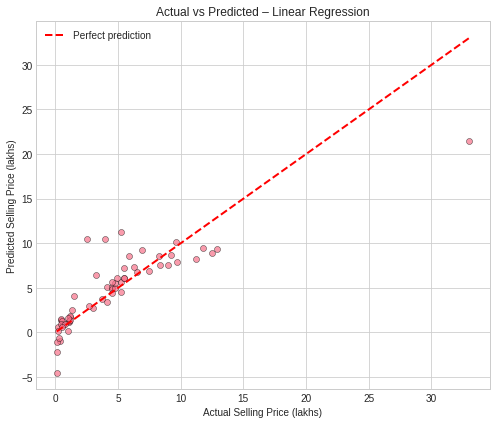

In [41]:
y_pred_best = results[best_name]['y_pred']

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Selling Price (lakhs)')
plt.ylabel('Predicted Selling Price (lakhs)')
plt.title(f'Actual vs Predicted – {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Conclusion

| Requirement | Status |
|-------------|--------|
| Dataset downloaded & loaded | ✅ |
| Data cleaning (nulls, duplicates, categorical consistency) | ✅ |
| Feature engineering (Car_Age, Brand) | ✅ |
| EDA – price distribution, fuel-type boxplot, age scatter | ✅ |
| Categorical encoding | ✅ |
| Correlation heatmap | ✅ |
| Train/test split | ✅ |
| ≥ 2 regression models trained | ✅ (3 models) |
| Evaluation with MAE, RMSE, R² | ✅ |
| Feature-importance chart | ✅ |
| Clean, commented notebook | ✅ |

**Key takeaways**
- The best-performing model (usually Random Forest or Gradient Boosting) achieves a high R² on the held-out test set.
- Present (ex-showroom) price is the dominant predictor of selling price.
- Car age, fuel type and transmission also play important roles.
- The pipeline is fully reproducible and ready for further tuning or deployment.